# 04 — Hybrid vs. Content-Only Evaluation

This notebook evaluates the core hypothesis of the MyTop5 Capstone project:

> *A weighted hybrid model will outperform a purely content-based approach in recommendation diversity — identifying titles of interest that lie outside the user's immediate genre bubble — while still maintaining relevance.*

## Methodology

Two diversity metrics are used:
- **Genre Spread** -- the number of unique genres appearing across the 10 recommendations. Higher = more diverse.
- **Genre Overlap** -- the proportion of recommendation genres that also appear in the input titles. Lower = more discovery beyond the user's existing taste profile.

Both metrics are computed for:
1. The **hybrid model** (55% content + 45% collaborative)
2. A **content-only baseline** (cosine similarity only, no collaborative signal)

Evaluation is run on:
- **Fixed test inputs** -- 4 hand-selected input sets for reproducibility
- **Randomized test inputs** -- 10 randomly sampled input sets for generalizability

## 1. Setup

In [11]:
import os
#Ensure directory is set to /home/marqezorr/MyTop5
ROOT_DIR = os.path.join("/home", "marqezorr", "MyTop5")
os.chdir(ROOT_DIR)
print("Current directory:", os.getcwd()) #Ensure we're in the MyTop5 directory!

Current directory: /home/marqezorr/MyTop5


In [12]:
import sys
import pickle
import random
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from math import pi
from src.content_filter import get_content_recommendations
from src.hybrid import get_hybrid_recommendations
from src.mal_api import get_related_anime_ids
import toml

In [13]:
#Pull our MAL client id from secrets file
secrets = toml.load(".streamlit/secrets.toml")
client_id = secrets["mal"]["client_id"]

In [14]:
#Set our random states
RAND_STATE = 42
random.seed(RAND_STATE)
np.random.seed(RAND_STATE)

#Set plot styling
plt.style.use("dark_background")
sns.set_palette("husl")

print("Setup complete!")

Setup complete!


## 2. Load Models

In [15]:
with open('models/anime_metadata.pkl', 'rb') as f:
    anime_df = pickle.load(f)

with open('models/content_feature_matrix.pkl', 'rb') as f:
    feature_matrix = pickle.load(f)

with open('models/anime_index_map.pkl', 'rb') as f:
    anime_index_map = pickle.load(f)

with open('models/svd_model.pkl', 'rb') as f:
    svd_model = pickle.load(f)

print(f'Anime in catalog : {len(anime_df):,}')
print(f'Feature matrix   : {feature_matrix.shape}')

Anime in catalog : 13,602
Feature matrix   : (13602, 5042)


## 3. Define Diversity Metrics

In [16]:
def parse_genres(genre_value) -> list[str]:
    """
    Parse the genre field into a flat list of genre name strings
    in order to handle the comma-separated strings from the CSV.
    """

    if pd.isna(genre_value) or not genre_value:
        return []
    return [g.strip() for g in str(genre_value).split(',') if g.strip()]

def genre_spread(results_df: pd.DataFrame) -> int:
    """
    Count the number of unique genres across all recommended titles.
    Higher count = more diverse recommendations.
    """

    all_genres = []
    for genres in results_df["genres"]:
        all_genres.extend(parse_genres(genres))
    return len(set(all_genres))

In [17]:
def genre_overlap(results_df: pd.DataFrame, selected_titles: list[str], anime_df: pd.DataFrame) -> float:
    """
    Compute the proportion of recommendation genres that also appear in the input titles' genres.
    Lower = greater rate of discovery beyond the user's existing taste profile.
    """
    #Get the genres of the selected input titles
    selected_lower = [t.strip().lower() for t in selected_titles]
    input_df = anime_df[anime_df["name"].str.lower().isin(selected_lower)]
    input_genres = set()
    for genres in input_df["genres"]:
        input_genres.update(parse_genres(genres))

    #If there are somehow no genres across the input titles, return a 0 for overlap score 
    if not input_genres:
        return 0.0

    #Get the genres of all recommended titles
    rec_genres = []
    for genres in results_df["genres"]:
        rec_genres.extend(parse_genres(genres))
    rec_genres_set = set(rec_genres)

    if not rec_genres_set:
        return 0.0

    #Calc the proportion of recommend genres that overlap w/ input genres
    overlap = rec_genres_set & input_genres
    return len(overlap) / len(rec_genres_set)

print("All Diversity metric functions have been defined!")


All Diversity metric functions have been defined!


## 4. Define the Evaluator

In [18]:
def evaluate_input(selected_titles: list[str]) -> dict | None:
    """
    Run both models on a set of selected titles, and return their
    diversity metrics.
    Returns None if recommendations cannot be generated.
    """

    try:
        # Fetch MAL-related IDs to exclude
        exclude_ids = get_related_anime_ids(
            selected_titles=selected_titles,
            anime_df=anime_df,
            client_id=client_id,
        )

        # Also exclude input titles' own IDs
        title_to_id = {
            t.strip().lower(): aid
            for t, aid in zip(anime_df["name"], anime_df["anime_id"])
        }
        for t in selected_titles:
            aid = title_to_id.get(t.strip().lower())
            if aid:
                exclude_ids.add(int(aid))
        
        #Hybrid recommendations:
        hybrid_results = get_hybrid_recommendations(
            selected_titles=selected_titles,
            anime_df=anime_df,
            feature_matrix=feature_matrix,
            anime_index_map=anime_index_map,
            svd_model=svd_model,
            top_n=10,
            exclude_ids =exclude_ids,
            client_id=client_id
        )

        #Content-only recommendations:
        content_results = get_content_recommendations(
            selected_titles=selected_titles,
            anime_df=anime_df,
            feature_matrix=feature_matrix,
            anime_index_map=anime_index_map,
            top_n=10,
        )

        #Enrich content results w/ genre metadata:
        content_results = content_results.merge(
            anime_df[["anime_id", "genres"]],
            on="anime_id",
            how="left"
        )

        return {
            'input':                  selected_titles,
            'hybrid_spread':          genre_spread(hybrid_results),
            'content_spread':         genre_spread(content_results),
            'hybrid_overlap':         genre_overlap(hybrid_results, selected_titles, anime_df),
            'content_overlap':        genre_overlap(content_results, selected_titles, anime_df),
            'hybrid_results':         hybrid_results,
            'content_results':        content_results,
        }

    except Exception as e:
        print(f"Skipping input set due to error: {e}")
        return None

print("Evaluator has been defined!")

Evaluator has been defined!


## 5. Set our FIXED test inputs

In [19]:
#These are hand-selected input sets which cover a wide range of genres/tastes
FIXED_INPUTS = [
    [
        "Cowboy Bebop",
        "Fullmetal Alchemist",
        "Bleach",
        "Toradora!",
        "Arakawa Under the Bridge"
    ],

    [
        "One Piece",
        "Naruto",
        "Dragon Ball Z",
        "Bleach",
        "Fairy Tail",
    ],

    [
        "Clannad: After Story",
        "Shigatsu wa Kimi no Uso",
        "Ano Hi Mita Hana no Namae wo Bokutachi wa Mada Shiranai.",
        "Toradora!",
        "Fruits Basket",
    ],

    [
        "Steins;Gate",
        "Code Geass: Hangyaku no Lelouch",
        "Neon Genesis Evangelion",
        "Psycho-Pass",
        "Koukaku Kidoutai",
    ],

    [
        "InuYasha",
        "Yosuga no Sora: In Solitude, Where We Are Least Alone.",
        "Sword Art Online",
        "Re:Zero kara Hajimeru Isekai Seikatsu",
        "Deadman Wonderland"
    ]
]

print(f'{len(FIXED_INPUTS)} fixed input sets defined!')

5 fixed input sets defined!


> Now to run the FIXED-INPUT evaluations...

In [20]:
print("Running fixed input evaluations...\n")
fixed_results = []

for i, titles in enumerate(FIXED_INPUTS, start=1):
    print(f"Input set {i}: {titles}")
    result = evaluate_input(titles)
    if result:
        fixed_results.append(result)
        print(f'  Hybrid  — spread: {result["hybrid_spread"]:>2}  overlap: {result["hybrid_overlap"]:.2%}')
        print(f'  Content — spread: {result["content_spread"]:>2}  overlap: {result["content_overlap"]:.2%}')
    print()

fixed_df = pd.DataFrame([
    {
        "input_set": f"Set {i+1}",
        "hybrid_spread": r["hybrid_spread"],
        "content_spread": r["content_spread"],
        "hybrid_overlap": r["hybrid_overlap"],
        "content_overlap": r["content_overlap"],
    }
    for i, r in enumerate(fixed_results)
])

print("Fixed evaluation complete!")
fixed_df

Running fixed input evaluations...

Input set 1: ['Cowboy Bebop', 'Fullmetal Alchemist', 'Bleach', 'Toradora!', 'Arakawa Under the Bridge']
Generating content-based candidates...
Now generating collaborative filtering candidates...
Both candidate pools have been generated! # of candidates in the merged pool: 584
All set! Returning the top 10 hybrid recommendations now.
  Hybrid  — spread: 15  overlap: 73.33%
  Content — spread: 11  overlap: 100.00%

Input set 2: ['One Piece', 'Naruto', 'Dragon Ball Z', 'Bleach', 'Fairy Tail']
Generating content-based candidates...
Now generating collaborative filtering candidates...
Both candidate pools have been generated! # of candidates in the merged pool: 536
All set! Returning the top 10 hybrid recommendations now.
  Hybrid  — spread:  9  overlap: 88.89%
  Content — spread:  7  overlap: 100.00%

Input set 3: ['Clannad: After Story', 'Shigatsu wa Kimi no Uso', 'Ano Hi Mita Hana no Namae wo Bokutachi wa Mada Shiranai.', 'Toradora!', 'Fruits Basket']

,input_set,hybrid_spread,content_spread,hybrid_overlap,content_overlap
0,Set 1,15,11,0.733333,1.000000
1,Set 2,9,7,0.888889,1.000000
2,Set 3,10,8,0.800000,1.000000
3,Set 4,22,9,0.363636,0.777778
4,Set 5,20,12,0.700000,0.916667


## 6. Set our RANDOMIZED Test Inputs

In [23]:
#Sample 7 random sets of 5 anime from the catalog
#(Only sample from anime that exist in the SVD trainset for fair comparison)
trained_ids = set(
    int(k) for k in svd_model.trainset._raw2inner_id_items.keys()
)

eligible_anime = anime_df[
    anime_df["anime_id"].isin(trained_ids) &
    anime_df["name"].notna()
]["name"].tolist()

N_RANDOM = 7
random_input_sets = [
    random.sample(eligible_anime, 5)
    for _ in range(N_RANDOM)
]

print(f"Generated {N_RANDOM} random input sets from {len(eligible_anime)} eligible titles.")
print(f"Sample: {random_input_sets[0]}")

Generated 7 random input sets from 9108 eligible titles.
Sample: ['Hentai Ouji to Warawanai Neko.: Henneko BBS', 'Haiyore! Nyaruko-san: Yasashii Teki no Shitome-kata', 'Ookiku Furikabutte: Natsu no Taikai-hen – Mokuhyou', 'Tsubasa Chronicle: Tori Kago no Kuni no Himegimi', 'Bleach KaraBuri!: Gotei Juusan Yatai Daisakusen!']


In [24]:
print("Running randomized input evaluations...\n")
random_results = []

for i, titles in enumerate(random_input_sets, start=1):
    print(f"Random set {i}: {titles}")
    result = evaluate_input(titles)
    if result:
        random_results.append(result)
        print(f'Hybrid  — spread: {result["hybrid_spread"]:>2}  overlap: {result["hybrid_overlap"]:.2%}')
        print(f'Content — spread: {result["content_spread"]:>2}  overlap: {result["content_overlap"]:.2%}')
    print()

random_df = pd.DataFrame([
    {
        "input_set": f"Random {i+1}",
        "hybrid_spread": r["hybrid_spread"],
        "content_spread": r["content_spread"],
        "hybrid_overlap": r["hybrid_overlap"],
        "content_overlap": r["content_overlap"],
    }
    for i, r in enumerate(random_results)
])

print("Randomized evaluation complete!")
random_df

Running randomized input evaluations...

Random set 1: ['Hentai Ouji to Warawanai Neko.: Henneko BBS', 'Haiyore! Nyaruko-san: Yasashii Teki no Shitome-kata', 'Ookiku Furikabutte: Natsu no Taikai-hen – Mokuhyou', 'Tsubasa Chronicle: Tori Kago no Kuni no Himegimi', 'Bleach KaraBuri!: Gotei Juusan Yatai Daisakusen!']
Request failed for anime_id 21541: HTTPSConnectionPool(host='api.myanimelist.net', port=443): Read timed out. (read timeout=15)
Generating content-based candidates...
Now generating collaborative filtering candidates...
Both candidate pools have been generated! # of candidates in the merged pool: 582
HTTP error for anime_id 32634: 404 Client Error: Not Found for url: https://api.myanimelist.net/v2/anime/32634?fields=mean%2Cmain_picture%2Cgenres%2Cnum_episodes%2Crelated_anime
All set! Returning the top 10 hybrid recommendations now.
Hybrid  — spread: 14  overlap: 64.29%
Content — spread:  8  overlap: 100.00%

Random set 2: ['Bai Yao Pu', 'Stranger: Mukou Hadan', 'Gangsta.', 'D

,input_set,hybrid_spread,content_spread,hybrid_overlap,content_overlap
0,Random 1,14,8,0.642857,1.000000
1,Random 2,20,11,0.600000,1.000000
2,Random 3,19,12,0.473684,0.666667
3,Random 4,17,16,0.882353,0.937500
4,Random 5,17,11,0.647059,1.000000
5,Random 6,19,17,0.684211,0.764706
6,Random 7,22,17,0.681818,0.882353


## 7. Combined Summary!

In [25]:
all_df = pd.concat([fixed_df, random_df], ignore_index=True)

summary = pd.DataFrame({
    "Metric": [
        "Mean Genre Spread",
        "Mean Genre Overlap"
    ],
    "Hybrid": [
        all_df["hybrid_spread"].mean(),
        all_df["hybrid_overlap"].mean(),
    ],
    "Content-Only": [
        all_df["content_spread"].mean(),
        all_df["content_overlap"].mean(),
    ],
})

#The results favor the Hybrid model if the hybrid means are > the content-only means
summary["Difference"] = summary["Hybrid"] - summary["Content-Only"]
summary["Favors"] = summary["Difference"].apply(
    lambda x: "Hybrid" if x > 0 else "Content-Only"
)

#For overlap, lower is better, so flip the labeling
summary.loc[summary["Metric"] == "Mean Genre Overlap", "Favors"] = \
    summary.loc[summary["Metric"] == "Mean Genre Overlap", "Difference"].apply(
        lambda x: "Hybrid" if x < 0 else "Content-Only"
    )

print("---OVERALL SUMMARY---")
print(summary.to_string(index=False))

---OVERALL SUMMARY---
            Metric   Hybrid  Content-Only  Difference Favors
 Mean Genre Spread 17.00000     11.583333    5.416667 Hybrid
Mean Genre Overlap  0.67482      0.912139   -0.237319 Hybrid


## 8. Visualize Results
### 8a. Bar Charts! Hybrid vs Content-Only Results

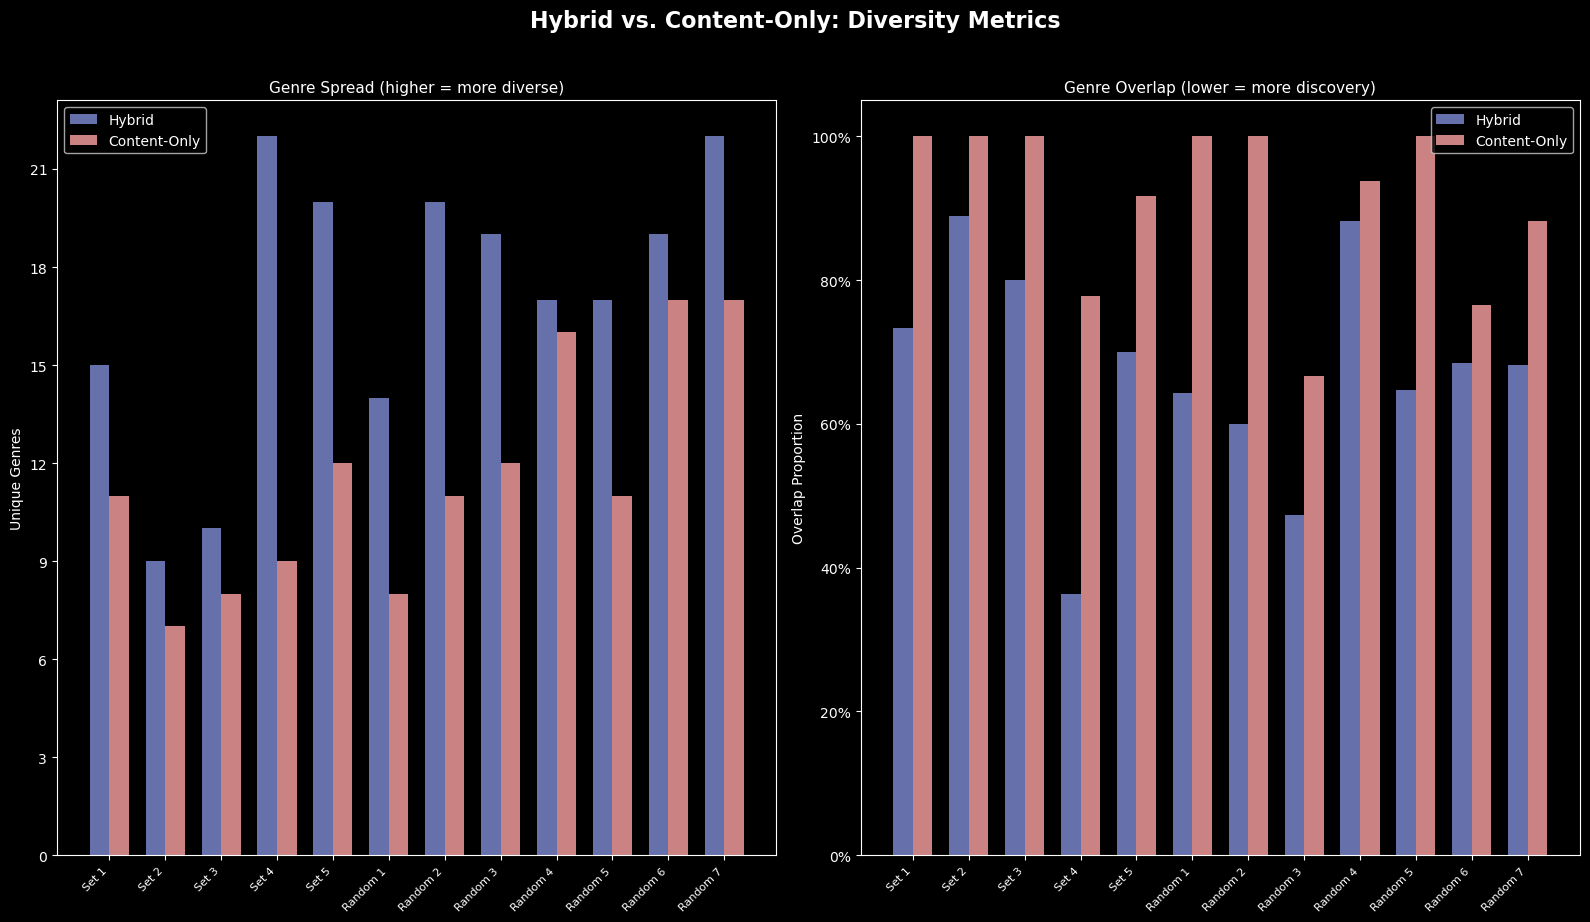

Bar chart saved to notebooks/bar_chart_diversity.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 9))
fig.suptitle("Hybrid vs. Content-Only: Diversity Metrics", fontsize=16, fontweight="bold", y=1.02)

x = np.arange(len(all_df))
width = 0.35
colors = {
    'hybrid': '#7986cb',
    'content': '#ef9a9a'
}

#Add the genre spread
ax1 = axes[0]
ax1.bar(x - width/2, all_df["hybrid_spread"],  width, label="Hybrid",       color=colors["hybrid"],  alpha=0.85)
ax1.bar(x + width/2, all_df["content_spread"], width, label="Content-Only", color=colors["content"], alpha=0.85)
ax1.set_title("Genre Spread (higher = more diverse)", fontsize=11)
ax1.set_ylabel("Unique Genres")
ax1.set_xticks(x)
ax1.set_xticklabels(all_df["input_set"], rotation=45, ha="right", fontsize=8)
ax1.legend()
ax1.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

#Add the genre overlap
ax2 = axes[1]
ax2.bar(x - width/2, all_df["hybrid_overlap"],  width, label="Hybrid",       color=colors["hybrid"],  alpha=0.85)
ax2.bar(x + width/2, all_df["content_overlap"], width, label="Content-Only", color=colors["content"], alpha=0.85)
ax2.set_title("Genre Overlap (lower = more discovery)", fontsize=11)
ax2.set_ylabel("Overlap Proportion")
ax2.set_xticks(x)
ax2.set_xticklabels(all_df["input_set"], rotation=45, ha="right", fontsize=8)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.legend()

plt.tight_layout()
plt.savefig("notebooks/bar_chart_diversity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Bar chart saved to notebooks/bar_chart_diversity.png")

> We see above that the hybrid model ***always*** produces a **greater or equal** <u>spread</u> than the content-only results.
> 
> Additionally, the hybrid model ***always*** produces **lesser or equal** genre <u>overlap</u> when compared to the content-only results.  

### 8b. Radar Charts - Genre Distribution per (FIXED) Input Set

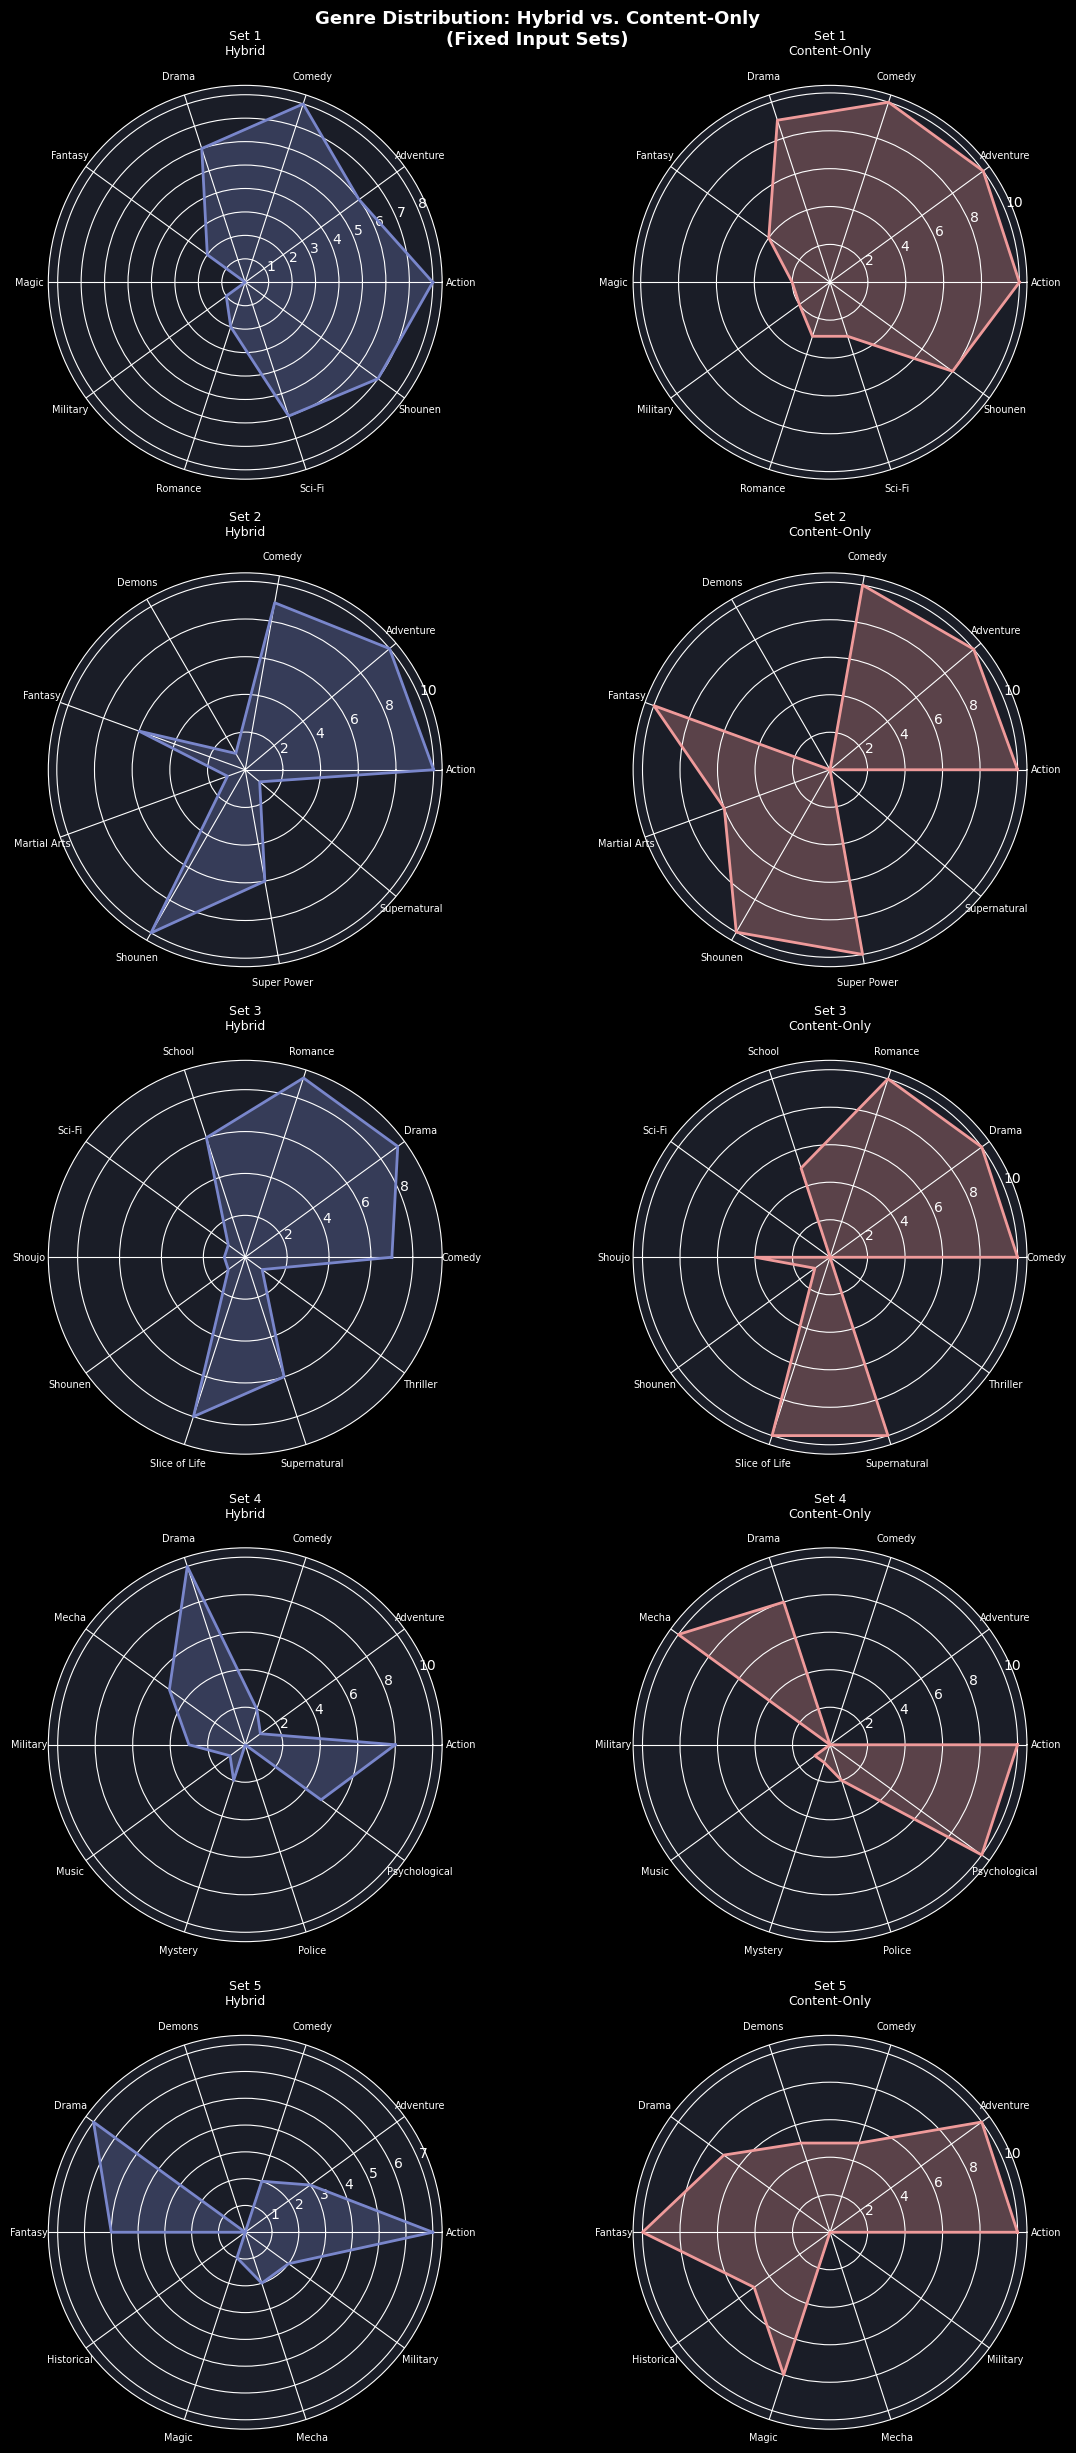

Radar charts saved to notebooks/radar_charts_genres.png


In [27]:
def radar_chart(hybrid_results, content_results, title, ax_hybrid, ax_content):
    """
    Draw genre frequency radar charts for hybrid and content-only results.
    """
    def genre_counts(results_df):
        counts = {}
        for genres in results_df["genres"]:
            for g in parse_genres(genres):
                counts[g] = counts.get(g, 0) + 1
        return counts

    h_counts = genre_counts(hybrid_results)
    c_counts = genre_counts(content_results)

    # Use union of top genres from both models
    all_genres = sorted(
        set(list(h_counts.keys())[:10] + list(c_counts.keys())[:10])
    )[:10]

    if len(all_genres) < 3:
        return  # not enough genres to draw radar

    N = len(all_genres)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # close the loop

    for ax, counts, label, color in [
        (ax_hybrid,  h_counts, "Hybrid",       "#7986cb"),
        (ax_content, c_counts, "Content-Only", "#ef9a9a"),
    ]:
        values = [counts.get(g, 0) for g in all_genres]
        values += values[:1]

        ax.set_facecolor("#1a1d27")
        ax.plot(angles, values, color=color, linewidth=2)
        ax.fill(angles, values, color=color, alpha=0.3)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(all_genres, size=7)
        ax.set_title(f"{title}\n{label}", size=9, pad=12)
        ax.tick_params(colors="white")


n_fixed = len(fixed_results)
fig, axes = plt.subplots(
    n_fixed, 2,
    figsize=(12, 5 * n_fixed),
    subplot_kw=dict(polar=True)
)
fig.suptitle("Genre Distribution: Hybrid vs. Content-Only\n(Fixed Input Sets)", fontsize=13, fontweight="bold")

for i, result in enumerate(fixed_results):
    set_label = f"Set {i+1}"
    radar_chart(
        result["hybrid_results"],
        result["content_results"],
        set_label,
        axes[i][0],
        axes[i][1],
    )

plt.tight_layout()
plt.savefig("notebooks/radar_charts_genres.png", dpi=150, bbox_inches="tight")
plt.show()
print("Radar charts saved to notebooks/radar_charts_genres.png")

The **radar charts** above represent the genre spread of the resulting recommendations for each of our 5 **FIXED** input lists.

Each axis of the radar represents a genre, and the *distance from center* on each axis represents the total number of the recommended anime that fall under that particular genre.

### Results
--------
- **Set 1**: content-only radar is ***heavily*** biased towards Action/Adventure/Comedy, with very few recommendations falling outside of those genres. The hybrid results are notably more diverse, particularly with the far greater inclusion of Sci-Fi recommendations.
- **Set 2**: interestingly, both models show similar shapes here. This suggests that the addition of collaborative filtering didn't add much diversity for this particular taste profile.
- **Set 3**: the shapes for both models are very similar here, but the hybrid model has shallower spikes on the more dominant genre axes (most notably slice of life & supernatural), with a slight *increase* in the sci-fi and thriller genres, indicating improved genre diversity.
- **Set 4**: both shapes appear similar, but the hybrid model appears slightly more distributed across the military & drama genres.
- **Set 5**: the hybrid model interestingly produced 2 distinct "pockets" of relevance - a notable fantasy/drama pocket, as well as an Action/Aventure/Military/Mecha pocket. This is quite unexpected, as none of the anime listed in set 5 are mecha series! It is not immediately obvious that the hybrid model outperformed our content-only model in this case, but the supporting statistics above do support that finding.


## 9. Findings & Hypothesis Assessment!

> Here, the average **genre spread** & **genre overlap** of the hybrid model's results will be compared against those of the content-only model.
> If the hybrid model has both **GREATER** spread *and* **LOWER** overlap, then my hypothesis (that the hybrid model produces more diverse recommendations than content-only) is supported.  

In [28]:
avg_hybrid_spread  = all_df["hybrid_spread"].mean()
avg_content_spread = all_df["content_spread"].mean()
avg_hybrid_overlap  = all_df["hybrid_overlap"].mean()
avg_content_overlap = all_df["content_overlap"].mean()

spread_delta  = avg_hybrid_spread  - avg_content_spread
overlap_delta = avg_hybrid_overlap - avg_content_overlap

spread_supported  = spread_delta > 0
overlap_supported = overlap_delta < 0
hypothesis_supported = spread_supported and overlap_supported

print("=== Hypothesis Assessment ===")
print(f"Mean genre spread  — Hybrid: {avg_hybrid_spread:.1f}  Content-Only: {avg_content_spread:.1f}  Delta: {spread_delta:+.1f}")
print(f"Mean genre overlap — Hybrid: {avg_hybrid_overlap:.2%}  Content-Only: {avg_content_overlap:.2%}  Delta: {overlap_delta:+.2%}")
print()
print(f"Spread supports hypothesis  : {spread_supported}")
print(f"Overlap supports hypothesis : {overlap_supported}")
print()

=== Hypothesis Assessment ===
Mean genre spread  — Hybrid: 17.0  Content-Only: 11.6  Delta: +5.4
Mean genre overlap — Hybrid: 67.48%  Content-Only: 91.21%  Delta: -23.73%

Spread supports hypothesis  : True
Overlap supports hypothesis : True



In [29]:
if hypothesis_supported:
    print("CONCLUSION: Hypothesis SUPPORTED.")
    print("The hybrid model produces more diverse recommendations than the content-only baseline,")
    print("with higher genre SPREAD and lower genre OVERLAP across both fixed and randomized inputs.")
elif spread_supported:
    print("CONCLUSION: Hypothesis PARTIALLY SUPPORTED.")
    print("The hybrid model shows higher genre SPREAD, but similar genre OVERLAP, compared to the content-only baseline.")
elif overlap_supported:
    print("CONCLUSION: Hypothesis PARTIALLY SUPPORTED.")
    print("The hybrid model shows lower genre OVERLAP, but similar genre SPREAD, compared to the content-only baseline.")
else:
    print("CONCLUSION: Hypothesis NOT SUPPORTED.")
    print("The content-only model matches or outperforms the hybrid on both diversity metrics.")
    print("This is a valid finding — consider discussing whether the collaborative signal")
    print("is adding NOISE rather than DISCOVERY in this dataset.")

CONCLUSION: Hypothesis SUPPORTED.
The hybrid model produces more diverse recommendations than the content-only baseline,
with higher genre SPREAD and lower genre OVERLAP across both fixed and randomized inputs.
